In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Storytelling_Autos").getOrCreate()

# Recuperar datos guardados en semanas anteriores
df_completos = spark.read.parquet("/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos")
df_kmeans = spark.read.parquet("/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans")

print("✅ Conexión establecida. Registros:", df_kmeans.count())


✅ Conexión establecida. Registros: 1988


✅ Datos recuperados: 2560 autos
✅ Clusters recuperados: 1988 autos
[KPI ESTRATÉGICO] - Concentración de mercado por marca
+----------+--------------+---------------------------------+
|     marca|Cantidad_Autos|Participacion_Catalogo_Porcentaje|
+----------+--------------+---------------------------------+
| Chevrolet|           215|                              8.4|
|      Ford|           208|                             8.13|
|   Peugeot|           196|                             7.66|
|    Nissan|           177|                             6.91|
|    Toyota|           138|                             5.39|
|     Chery|           121|                             4.73|
|   Hyundai|           105|                              4.1|
|       Kia|            98|                             3.83|
|        Mg|            92|                             3.59|
|Volkswagen|            90|                             3.52|
+----------+--------------+---------------------------------+
only showi

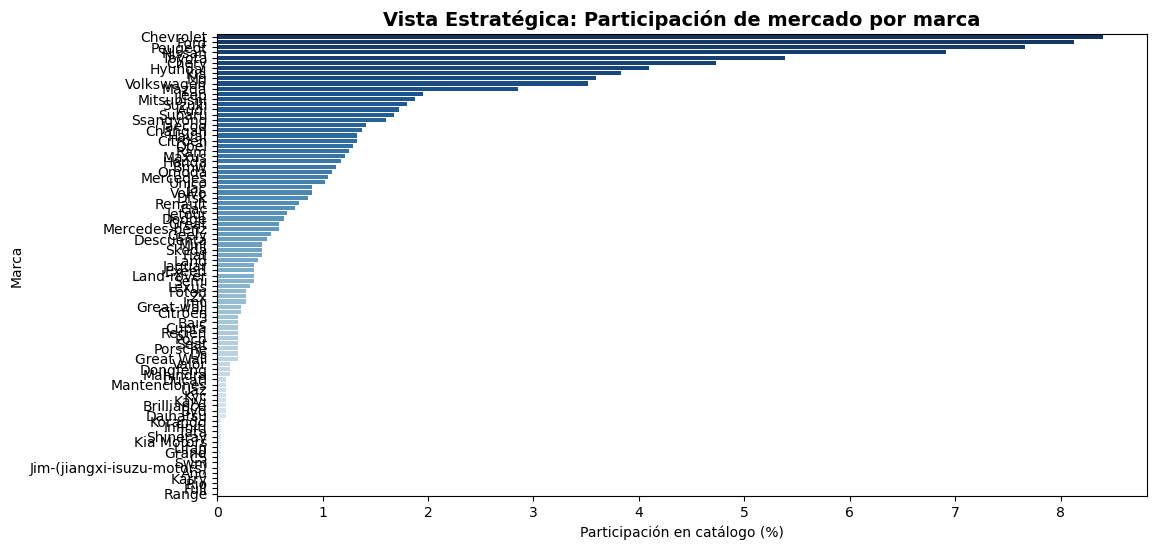

[KPI TÁCTICO] - Volatilidad y competitividad de precios
+-------------+-------------+---------------+-------------+---------------------------+
|        marca|Precio_Minimo|Precio_Promedio|Precio_Maximo|Desviacion_Estandar_Precios|
+-------------+-------------+---------------+-------------+---------------------------+
|        Lexus|      15296.0|        45458.0|      99684.0|                    28681.0|
|      Porsche|      22959.0|        41527.0|      84276.0|                    26229.0|
|         Audi|      13153.0|        32091.0|     115296.0|                    20241.0|
|Mercedes-benz|       8459.0|        33248.0|      83643.0|                    19283.0|
|        Valor|      11112.0|        28935.0|      45398.0|                    17183.0|
|   Land-rover|      14888.0|        37688.0|      52439.0|                    14795.0|
|         Ford|       5306.0|        25864.0|      86724.0|                    13525.0|
|          Bmw|       9071.0|        26574.0|      61194.0|     

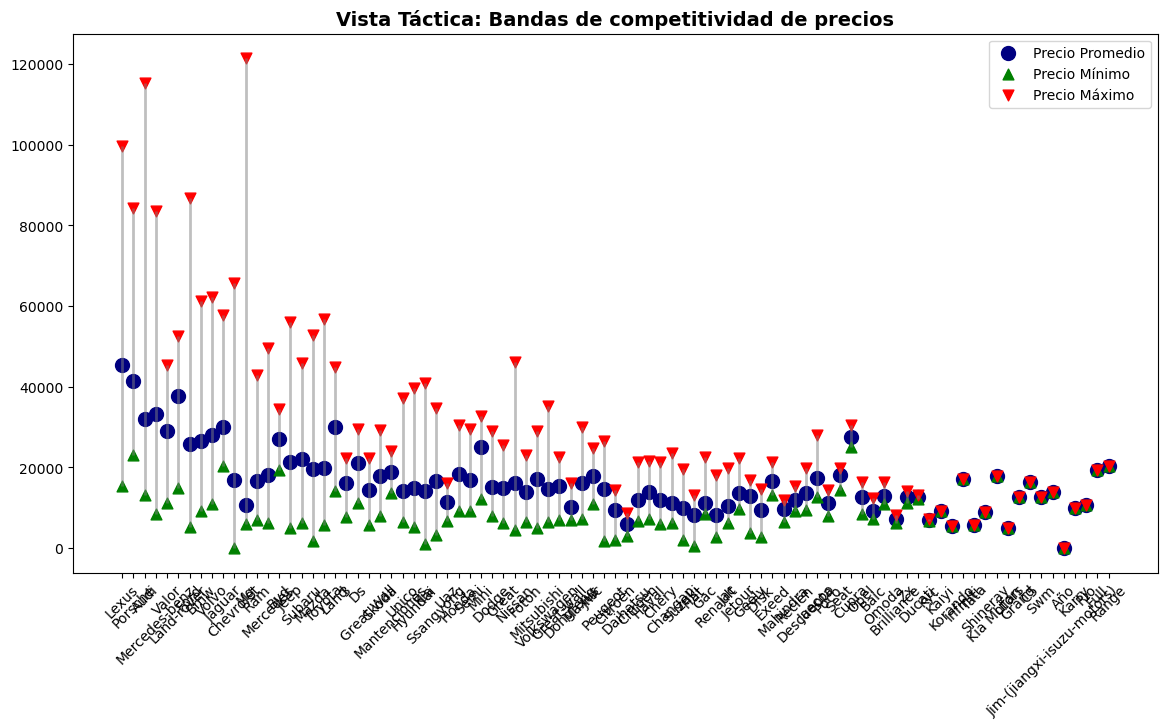

[KPI OPERACIONAL] - Alertas críticas (Total: 7)
+---------+------------+------------------+---------------+----+
|    marca|      modelo|        precio_eur|kilometraje_num|year|
+---------+------------+------------------+---------------+----+
|Chevrolet|    Suburban| 10.10204081632653|         300000|2011|
|   Suzuki|Grand Nomade| 3214.285714285714|         221000|2007|
|     Fiat|       Palio|459.18367346938777|         320000|2002|
|  Peugeot|         301|4061.2244897959185|         235000|2016|
|  Peugeot|         307|2551.0204081632655|         226558|2007|
|Chevrolet|         Luv|2857.1428571428573|         260000|1995|
|  Peugeot|     Partner| 1836.734693877551|         314450|2010|
+---------+------------+------------------+---------------+----+



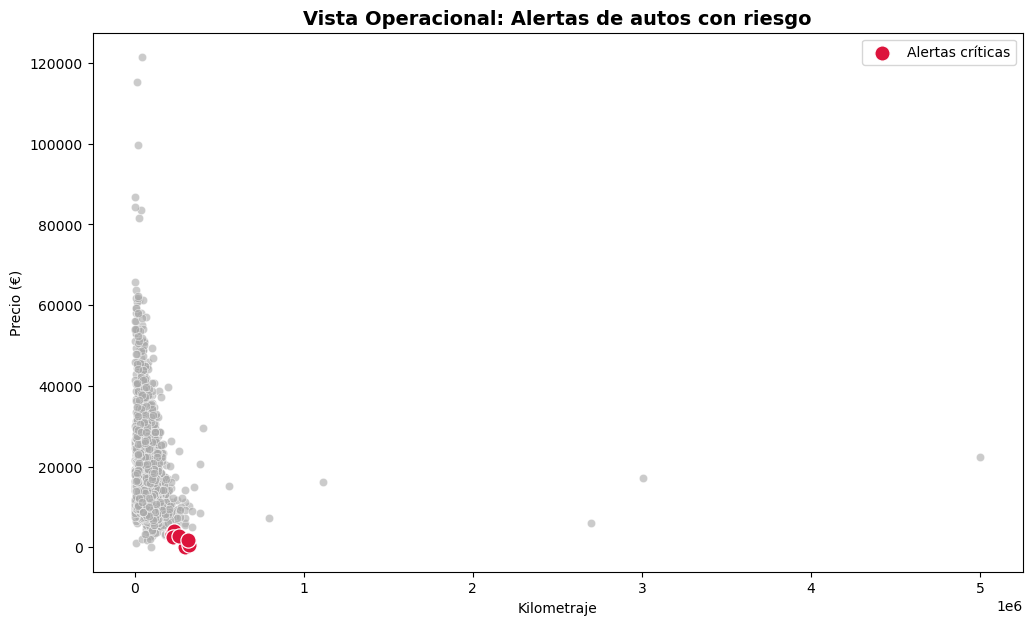

In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sesión Spark y carga de datos
spark = SparkSession.builder.appName("Storytelling_Autos").getOrCreate()

df_completos = spark.read.parquet("/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos")
df_kmeans = spark.read.parquet("/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans")

print("✅ Datos recuperados:", df_completos.count(), "autos")
print("✅ Clusters recuperados:", df_kmeans.count(), "autos")

# ============================================================
# 2. KPI Estratégico (CEO / Director) - Participación de mercado por marca
# ============================================================
total_autos = df_completos.count()
kpi_estrategico = df_completos.groupBy("marca") \
    .agg(
        F.count("marca").alias("Cantidad_Autos"),
        F.round((F.count("marca") / total_autos) * 100, 2).alias("Participacion_Catalogo_Porcentaje")
    ).orderBy(F.desc("Cantidad_Autos"))

print("[KPI ESTRATÉGICO] - Concentración de mercado por marca")
kpi_estrategico.show(10)

# Gráfico Estratégico
df_est_pandas = kpi_estrategico.toPandas()
plt.figure(figsize=(12,6))
sns.barplot(
    x="Participacion_Catalogo_Porcentaje",
    y="marca",
    data=df_est_pandas,
    hue="marca", dodge=False, legend=False,
    palette="Blues_r"
)
plt.title("Vista Estratégica: Participación de mercado por marca", fontsize=14, fontweight="bold")
plt.xlabel("Participación en catálogo (%)")
plt.ylabel("Marca")
plt.show()

# ============================================================
# 3. KPI Táctico (Gerente Comercial) - Dispersión de precios
# ============================================================
kpi_tactico = df_completos.groupBy("marca") \
    .agg(
        F.round(F.min("precio_eur"), 0).alias("Precio_Minimo"),
        F.round(F.avg("precio_eur"), 0).alias("Precio_Promedio"),
        F.round(F.max("precio_eur"), 0).alias("Precio_Maximo"),
        F.round(F.stddev("precio_eur"), 0).alias("Desviacion_Estandar_Precios")
    ).orderBy(F.desc("Desviacion_Estandar_Precios"))

print("[KPI TÁCTICO] - Volatilidad y competitividad de precios")
kpi_tactico.show(10)

# Gráfico Táctico
df_tac_pandas = kpi_tactico.toPandas()
plt.figure(figsize=(14,7))
plt.vlines(x=df_tac_pandas["marca"], ymin=df_tac_pandas["Precio_Minimo"], ymax=df_tac_pandas["Precio_Maximo"], colors="gray", alpha=0.5, linewidth=2)
plt.scatter(df_tac_pandas["marca"], df_tac_pandas["Precio_Promedio"], color="navy", s=100, label="Precio Promedio")
plt.scatter(df_tac_pandas["marca"], df_tac_pandas["Precio_Minimo"], color="green", marker="^", s=60, label="Precio Mínimo")
plt.scatter(df_tac_pandas["marca"], df_tac_pandas["Precio_Maximo"], color="red", marker="v", s=60, label="Precio Máximo")
plt.title("Vista Táctica: Bandas de competitividad de precios", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# ============================================================
# 4. KPI Operacional (Supervisor) - Alertas críticas
# ============================================================
kpi_operacional_alertas = df_completos.filter((F.col("kilometraje_num") > 200000) & (F.col("precio_eur") < 5000)) \
    .select("marca","modelo","precio_eur","kilometraje_num","year")

print(f"[KPI OPERACIONAL] - Alertas críticas (Total: {kpi_operacional_alertas.count()})")
kpi_operacional_alertas.show(10)

# Gráfico Operacional
df_op_pandas = df_completos.select("precio_eur","kilometraje_num").toPandas()
plt.figure(figsize=(12,7))
sns.scatterplot(x="kilometraje_num", y="precio_eur", data=df_op_pandas, alpha=0.6, color="darkgray", legend=False)
zona_peligro = df_op_pandas[(df_op_pandas["kilometraje_num"] > 200000) & (df_op_pandas["precio_eur"] < 5000)]
sns.scatterplot(x="kilometraje_num", y="precio_eur", data=zona_peligro, color="crimson", s=120, label="Alertas críticas")
plt.title("Vista Operacional: Alertas de autos con riesgo", fontsize=14, fontweight="bold")
plt.xlabel("Kilometraje")
plt.ylabel("Precio (€)")
plt.legend()
plt.show()


In [1]:
from pyspark.sql import SparkSession
import os

# Crear sesión Spark
spark = SparkSession.builder.appName("Exportar_Autos").getOrCreate()

# Recuperar el DataFrame limpio desde Semana 9
df_completos = spark.read.parquet("/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos")

# Crear carpeta Semana 15 si no existe
output_dir = "/home/jovyan/work/semanas/Semana 15"
os.makedirs(output_dir, exist_ok=True)

# Exportar a CSV para Streamlit
csv_path = os.path.join(output_dir, "datos_autos_dashboard.csv")
df_completos.toPandas().to_csv(csv_path, index=False)

print(f"✅ Datos exportados listos para Streamlit en: {csv_path}")


✅ Datos exportados listos para Streamlit en: /home/jovyan/work/semanas/Semana 15/datos_autos_dashboard.csv


In [3]:
df_completos.toPandas().to_csv(
    "/home/jovyan/work/autotec/semana 15/datos_autotec_dashboard.csv",
    index=False
)